In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import torch
from torchvision import models
import torch.nn as nn
import zipfile
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import umap.umap_ as umap
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score,train_test_split,StratifiedKFold
from sklearn.metrics import roc_auc_score
from PIL import Image
from skimage.color import rgb2lab
from skimage.filters import sobel, laplace, threshold_otsu
from sklearn.pipeline import make_pipeline
import lightgbm as lgb
import warnings
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics.pairwise import pairwise_distances


edge_path = '/content/drive/MyDrive/Data/augmented_leafs.zip'
chaos_path = '/content/drive/MyDrive/Data/chaos.zip'
model_path = '/content/drive/MyDrive/Data/tomato_efficientnet_b0_finetuned(2).pth'

model = models.efficientnet_b0(weights=None)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, 10)

state = torch.load(model_path, map_location='cpu')
model.load_state_dict(state)

model.eval();

In [23]:
for z, out in [(chaos_path, 'chaos'), (edge_path, 'edge')]:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(out)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
chaos_ds = datasets.ImageFolder('chaos', transform=transform)
edge_ds  = datasets.ImageFolder('edge', transform=transform)
chaos_loader = DataLoader(chaos_ds, batch_size=64, shuffle=False)
edge_loader  = DataLoader(edge_ds,  batch_size=64, shuffle=False)


In [24]:
def extract_pixel_features_from_path(path, label_name):
    img = Image.open(path).convert("RGB")
    img = img.resize((224, 224))
    arr = np.array(img).astype(np.float32) / 255.0

    H, W, _ = arr.shape

    R = arr[:, :, 0]
    G = arr[:, :, 1]
    B = arr[:, :, 2]

    R_mean, G_mean, B_mean = R.mean(), G.mean(), B.mean()
    R_std,  G_std,  B_std  = R.std(),  G.std(),  B.std()
    lab = rgb2lab(arr)
    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    L_mean, a_mean, b_mean = L.mean(), a.mean(), b.mean()
    L_std,  a_std,  b_std  = L.std(),  a.std(),  b.std()
    gray = arr.mean(axis=2)
    sob = sobel(gray)
    lap = laplace(gray)

    sobel_mean = sob.mean()
    sobel_std  = sob.std()
    lap_var    = lap.var()
    try:
        t = threshold_otsu(gray)
        mask = gray < t
    except ValueError:
        mask = gray > gray.mean()

    leaf_area_ratio = mask.mean()

    ys, xs = np.where(mask)
    if len(ys) > 0:
        cy = ys.mean() / H
        cx = xs.mean() / W
    else:
        cy, cx = 0.5, 0.5

    return {
        "path": path,
        "high_level_label": label_name,
        "R_mean": R_mean, "G_mean": G_mean, "B_mean": B_mean,
        "R_std":  R_std,  "G_std":  G_std,  "B_std":  B_std,
        "L_mean": L_mean, "a_mean": a_mean, "b_mean": b_mean,
        "L_std":  L_std,  "a_std":  a_std,  "b_std":  b_std,
        "sobel_mean": sobel_mean,
        "sobel_std":  sobel_std,
        "lap_var":    lap_var,
        "leaf_area_ratio": leaf_area_ratio,
        "leaf_cx": cx,
        "leaf_cy": cy,
    }


In [25]:

rows = []
import pandas as pd
for path, _ in chaos_ds.samples:
    rows.append(extract_pixel_features_from_path(path, label_name="chaos"))

for path, _ in edge_ds.samples:
    rows.append(extract_pixel_features_from_path(path, label_name="edge"))

df_pix = pd.DataFrame(rows)
df_pix["label_id"] = (df_pix["high_level_label"] == "edge").astype(int)  # chaos=0, edge=1

df_pix.head()


,path,high_level_label,R_mean,G_mean,B_mean,R_std,G_std,B_std,L_mean,a_mean,...,L_std,a_std,b_std,sobel_mean,sobel_std,lap_var,leaf_area_ratio,leaf_cx,leaf_cy,label_id
0,chaos/chaos/Tomato___Bacterial_spot/01a3cf3f-9...,chaos,0.549448,0.543211,0.546697,0.111606,0.129844,0.119979,57.565434,0.996085,...,12.999972,5.623992,4.770562,0.016681,0.021062,0.005304,0.108797,0.413873,0.571846,0
1,chaos/chaos/Tomato___Bacterial_spot/01a3cf3f-9...,chaos,0.524523,0.503182,0.514126,0.103052,0.135195,0.118875,54.013107,2.885067,...,12.845367,6.203454,4.186236,0.017190,0.018506,0.003003,0.284100,0.334147,0.623063,0
2,chaos/chaos/Tomato___Bacterial_spot/01a3cf3f-9...,chaos,0.543306,0.524076,0.534795,0.086088,0.111282,0.097217,56.153336,2.581830,...,10.390469,6.505724,4.885272,0.019275,0.019042,0.004473,0.250937,0.584679,0.291068,0
3,chaos/chaos/Tomato___Bacterial_spot/01a3cf3f-9...,chaos,0.459925,0.431761,0.446813,0.161089,0.196860,0.177821,46.506802,4.080422,...,19.672230,5.930922,3.105508,0.015305,0.022369,0.000218,0.382274,0.410681,0.616487,0
4,chaos/chaos/Tomato___Bacterial_spot/01a3cf3f-9...,chaos,0.565993,0.560216,0.563227,0.080006,0.099151,0.088870,59.363556,0.857173,...,9.609510,5.041558,4.128582,0.014073,0.017666,0.004067,0.074418,0.353720,0.716978,0


In [26]:
all_feature_cols = [
    c for c in df_pix.columns
    if c not in ["path", "high_level_label", "label_id"]
]

color_cols = [
    c for c in all_feature_cols
    if c.startswith(("R_", "G_", "B_", "L_", "a_", "b_"))
]

non_color_cols = [c for c in all_feature_cols if c not in color_cols]

X_all      = df_pix[all_feature_cols].values
X_nocolor  = df_pix[non_color_cols].values
y          = df_pix["label_id"].values


In [27]:
warnings.filterwarnings("ignore", message="X does not have valid feature names")


def eval_lgbm(X, y, name):
    clf = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        n_jobs=-1,
        verbose=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    acc = cross_val_score(clf, X, y, cv=cv, scoring="accuracy").mean()
    auc = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc").mean()

    print(f"{name} (LightGBM) -> Acc: {acc:.3f}, ROC-AUC: {auc:.3f}")
eval_lgbm(X_all,     y, "WITH color features")
eval_lgbm(X_nocolor, y, "WITHOUT color features")


WITH color features (LightGBM) -> Acc: 0.890, ROC-AUC: 0.957
WITHOUT color features (LightGBM) -> Acc: 0.667, ROC-AUC: 0.543


In [28]:
feature_cols = [
    c for c in df_pix.columns
    if c not in ["path", "high_level_label", "label_id"]
]

X = df_pix[feature_cols].values
y = df_pix["label_id"].values

clf = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    n_jobs=-1,
    verbose=-1
)

clf.fit(X, y)

imp = clf.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": imp
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
8,b_mean,1098
7,a_mean,1014
10,a_std,939
11,b_std,891
16,leaf_cx,789
13,sobel_std,771
14,lap_var,720
5,B_std,718
4,G_std,680
12,sobel_mean,654


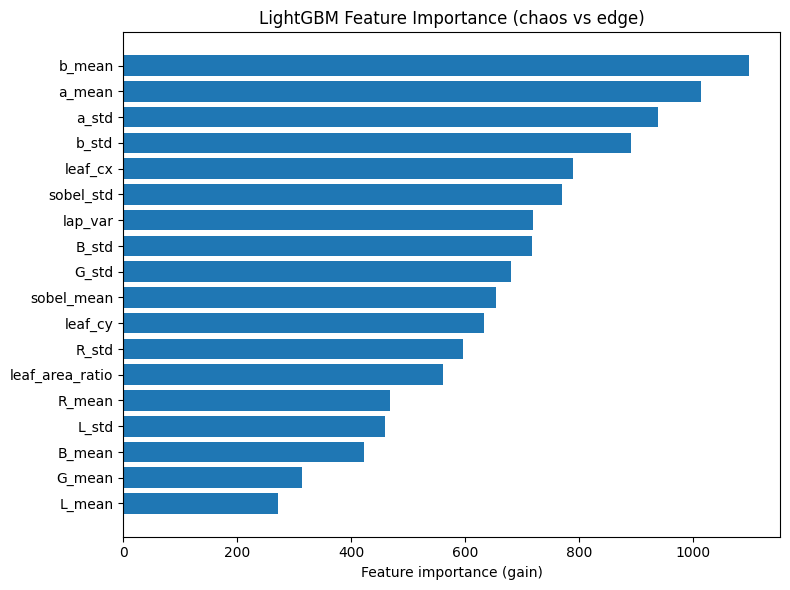

In [29]:
top = importance_df.head(20)
plt.figure(figsize=(8, 6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Feature importance (gain)")
plt.title("LightGBM Feature Importance (chaos vs edge)")
plt.tight_layout()
plt.show()


In [30]:
mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_df = pd.DataFrame({
    "feature": feature_cols,
    "mi": mi
}).sort_values("mi", ascending=False)

mi_df.head(20)


,feature,mi
8,b_mean,0.278951
7,a_mean,0.185578
4,G_std,0.030300
2,B_mean,0.029433
10,a_std,0.027949
5,B_std,0.021969
9,L_std,0.016971
1,G_mean,0.016241
11,b_std,0.013220
13,sobel_std,0.007223


In [31]:
def extract_features(dataloader, model, device="cuda"):
    feats = []
    with torch.no_grad():
        for imgs, _ in dataloader:
            imgs = imgs.to(device, non_blocking=True)
            f = model(imgs)
            f = f.detach().cpu()
            feats.append(f)
    return torch.cat(feats, dim=0)

class EffNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.pool = model.avgpool
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return x
device = torch.device("cuda")

feat_model = EffNetFeatureExtractor(model).to(device)
feat_model.eval();


In [32]:
from torchvision.datasets import ImageFolder
gray_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

rgb_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

chaos_rgb_ds = ImageFolder("chaos", transform=rgb_transform)
edge_rgb_ds  = ImageFolder("edge",  transform=rgb_transform)

chaos_rgb_loader = DataLoader(chaos_rgb_ds, batch_size=64, shuffle=False)
edge_rgb_loader  = DataLoader(edge_rgb_ds,  batch_size=64, shuffle=False)

chaos_rgb_feats = extract_features(chaos_rgb_loader, feat_model)
edge_rgb_feats  = extract_features(edge_rgb_loader,  feat_model)

chaos_rgb_np = chaos_rgb_feats.detach().cpu().numpy()
edge_rgb_np  = edge_rgb_feats.detach().cpu().numpy()



chaos_gray_ds = ImageFolder("chaos", transform=gray_transform)
edge_gray_ds  = ImageFolder("edge",  transform=gray_transform)

chaos_gray_loader = DataLoader(chaos_gray_ds, batch_size=64, shuffle=False)
edge_gray_loader  = DataLoader(edge_gray_ds,  batch_size=64, shuffle=False)

chaos_gray_feats = extract_features(chaos_gray_loader, feat_model)
edge_gray_feats  = extract_features(edge_gray_loader,  feat_model)

chaos_gray_np = chaos_gray_feats.detach().cpu().numpy()
edge_gray_np  = edge_gray_feats.detach().cpu().numpy()

In [33]:
X_rgb  = np.vstack([chaos_rgb_np,  edge_rgb_np])
X_gray = np.vstack([chaos_gray_np, edge_gray_np])


y = np.hstack([
    np.ones(len(chaos_rgb_np)),  # chaos = 1
    np.zeros(len(edge_rgb_np))   # edge = 0
])

eval_lgbm(X_rgb,  y, "WITH RGB features")
eval_lgbm(X_gray, y, "WITH grayscale features")


WITH RGB features (LightGBM) -> Acc: 0.874, ROC-AUC: 0.943
WITH grayscale features (LightGBM) -> Acc: 0.731, ROC-AUC: 0.781
